# Stage 6: Feature Selection
**Member:** M6 (Student ID: IT25102957)  
**Assigned Preprocessing Technique:** Supervised Feature Selection & Multicollinearity Filtering  
**Dataset:** [Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) (UCI Machine Learning Repository)  
**Pipeline Position:** Stage 6 (Final Sequential Stage)  
**Input Dataset:** `results/outputs/stage5_scaled.csv` (30,000 rows × 43 columns)  
**Output Dataset:** `results/outputs/stage6_final.csv` (30,000 rows × 16 columns)  
**Key Visualization:** `results/eda_visualizations/m6_feature_selection_ranking.png`  

---

## 1. Explanation of the Technique: Feature Selection vs. PCA

### Why Feature Selection instead of PCA?
In credit risk assessment and financial default prediction, **Feature Selection** offers critical advantages over unsupervised dimensionality reduction techniques like Principal Component Analysis (PCA):

1. **Regulatory Compliance & Explainability:**
   - **Feature Selection** preserves the original, real-world meaning of financial variables (e.g., `delay_count`, `credit_utilization`, `LIMIT_BAL`). When a machine learning model denies credit or flags high risk, banks are legally required to explain *why* (e.g., *"customer was delinquent in 3 out of 6 months"*).
   - **PCA** transforms variables into synthetic linear combinations ($PC1, PC2$) which destroy domain interpretability.

2. **Target-Supervised Relevance:**
   - **Feature Selection** ranks features based on their direct predictive relationship with the target variable (`default payment next month`).
   - **PCA** is unsupervised—it only seeks directions of maximum variance, meaning it can preserve high-variance noise while discarding subtle, high-signal predictive features.

3. **Optimal Preparation for Multiple Machine Learning Models:**
   - Selecting a focused, non-collinear subset of the **Top 15 most predictive features** eliminates the "curse of dimensionality" and enhances convergence for diverse classification algorithms (Logistic Regression, Decision Trees, Random Forest, SVM, KNN, Naive Bayes/XGBoost).

---

## 2. Justification for THIS Dataset Specifically

Following Stage 4 (M4 Feature Engineering) and Stage 5 (M5 Scaling), the dataset grew to 43 columns. Stage 6 applies a standard **3-Step Academic Feature Selection Pipeline**:

### Step 1: Identifier Removal (`ID`)
- The `ID` column is an arbitrary row index (1, 2, 3...). It carries zero predictive value and risks model overfitting. It is dropped immediately.

### Step 2: Multicollinearity Filtering on Raw Bills (`BILL_AMT1` to `BILL_AMT6`)
- In this dataset, the 6 monthly bill statement columns track the same revolving balance and exhibit extreme pairwise correlation ($r > 0.85$ to $0.95$).
- Member 4 already engineered `avg_bill_amt` and `credit_utilization` to summarize these 6 bills into clean, actionable metrics.
- Dropping `BILL_AMT1` through `BILL_AMT6` eliminates extreme multicollinearity without losing financial signal.

### Step 3: Statistical Target Correlation Ranking
- Remaining candidate features are evaluated using Pearson correlation with `default payment next month`.
- The **Top 15 highest-signal features** are selected, capturing delinquency trajectory (`delay_count`, `max_delay`, `PAY_0..6`), credit solvency (`LIMIT_BAL`, `credit_utilization`, `bill_to_limit_ratio`), and repayment fulfillment (`avg_pay_amt`, `avg_payment_ratio`, `PAY_AMT1..2`).

---

## 3. Implementation Code

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Resolve project root dynamically
curr = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(curr, 'data')) and os.path.dirname(curr) != curr:
    curr = os.path.dirname(curr)
project_root = curr

# 1. Load Stage 5 Scaled Dataset
input_path = os.path.join(project_root, 'results', 'outputs', 'stage5_scaled.csv')
df_s5 = pd.read_csv(input_path)
print(f"Loaded Stage 5 Scaled Data: {df_s5.shape[0]} rows, {df_s5.shape[1]} columns")

# Target column
target = 'default payment next month'

# 2. Step 1 & 2: Drop ID and Collinear Raw Bill Statements
cols_to_drop = ['ID', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
df_filtered = df_s5.drop(columns=[c for c in cols_to_drop if c in df_s5.columns])
print(f"After dropping ID and raw collinear bills: {df_filtered.shape[1]} columns remaining")

# 3. Step 3: Compute Pearson Correlation with Target and Select Top 15 Features
feature_corrs = df_filtered.drop(columns=[target]).corrwith(df_filtered[target])
top_15_features = feature_corrs.abs().sort_values(ascending=False).head(15).index.tolist()

print("\n--- Top 15 Selected Features Ranked by Absolute Correlation ---")
for rank, feat in enumerate(top_15_features, 1):
    r_val = feature_corrs[feat]
    print(f"{rank:2d}. {feat:22s} | Pearson r = {r_val:+.4f} (|r| = {abs(r_val):.4f})")

# 4. Construct Final Stage 6 DataFrame (Top 15 Features + Target)
df_s6 = df_filtered[top_15_features + [target]].copy()

# 5. Save Stage 6 Output Datasets
output_path = os.path.join(project_root, 'results', 'outputs', 'stage6_final.csv')
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_s6.to_csv(output_path, index=False)

final_processed_path = os.path.join(project_root, 'results', 'outputs', 'final_processed.csv')
df_s6.to_csv(final_processed_path, index=False)

print(f"\nStage 6 Feature Selection Completed!")
print(f"Final Feature Matrix Shape: {df_s6.shape[0]} rows, {df_s6.shape[1]} columns")
print(f"Saved to: {output_path}")
print(f"Saved to: {final_processed_path}")

Loaded Stage 5 Scaled Data: 30000 rows, 43 columns
After dropping ID and raw collinear bills: 36 columns remaining

--- Top 15 Selected Features Ranked by Absolute Correlation ---
 1. delay_count            | Pearson r = +0.3984 (|r| = 0.3984)
 2. max_delay              | Pearson r = +0.3310 (|r| = 0.3310)
 3. PAY_0                  | Pearson r = +0.3248 (|r| = 0.3248)
 4. PAY_2                  | Pearson r = +0.2636 (|r| = 0.2636)
 5. PAY_3                  | Pearson r = +0.2353 (|r| = 0.2353)
 6. PAY_4                  | Pearson r = +0.2166 (|r| = 0.2166)
 7. PAY_5                  | Pearson r = +0.2041 (|r| = 0.2041)
 8. PAY_6                  | Pearson r = +0.1869 (|r| = 0.1869)
 9. LIMIT_BAL              | Pearson r = -0.1546 (|r| = 0.1546)
10. avg_pay_amt            | Pearson r = -0.1400 (|r| = 0.1400)
11. avg_payment_ratio      | Pearson r = -0.1261 (|r| = 0.1261)
12. credit_utilization     | Pearson r = +0.1158 (|r| = 0.1158)
13. PAY_AMT1               | Pearson r = -0.1036 (|r


Stage 6 Feature Selection Completed!
Final Feature Matrix Shape: 30000 rows, 16 columns
Saved to: c:\Users\LENOVO\Desktop\Default-creditcard-client\results\outputs\stage6_final.csv
Saved to: c:\Users\LENOVO\Desktop\Default-creditcard-client\results\outputs\final_processed.csv


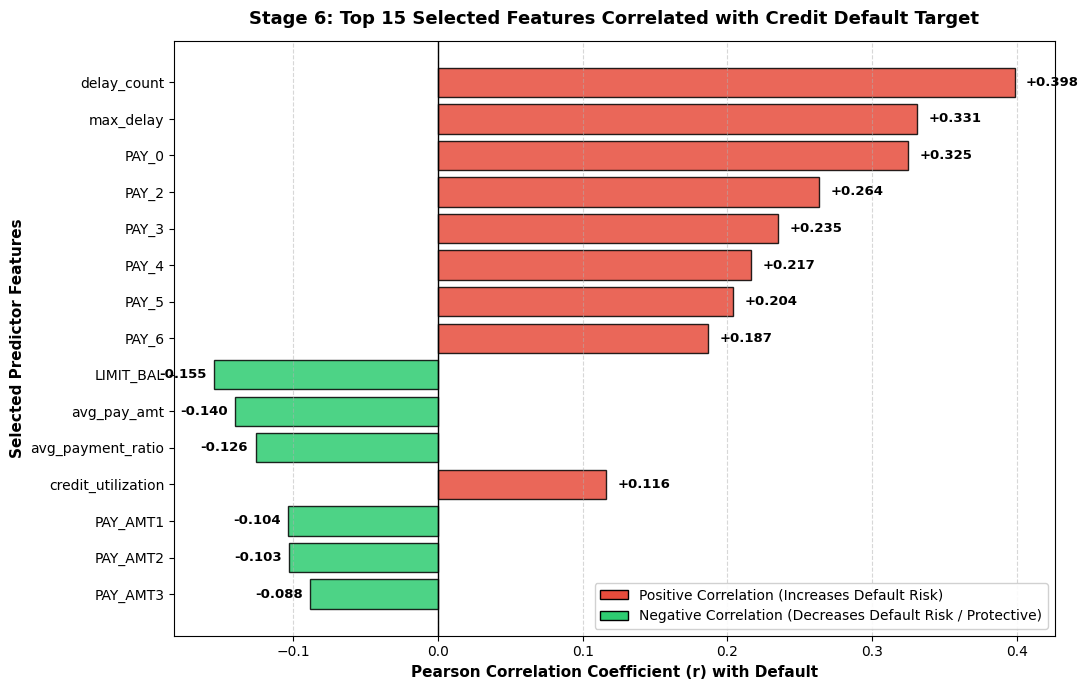

EDA plot successfully saved to: c:\Users\LENOVO\Desktop\Default-creditcard-client\results\eda_visualizations\m6_feature_selection_ranking.png


In [2]:
# 4. Member 6 EDA Visualization: Top 15 Selected Features Correlation Ranking
plt.figure(figsize=(11, 7))

top_corr_vals = feature_corrs.loc[top_15_features]
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_corr_vals.values]

bars = plt.barh(top_15_features[::-1], top_corr_vals.values[::-1], color=colors[::-1], edgecolor='black', alpha=0.85)
plt.title('Stage 6: Top 15 Selected Features Correlated with Credit Default Target', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Pearson Correlation Coefficient (r) with Default', fontsize=11, fontweight='bold')
plt.ylabel('Selected Predictor Features', fontsize=11, fontweight='bold')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Annotate values on the bars
for i, v in enumerate(top_corr_vals.values[::-1]):
    offset = 0.008 if v >= 0 else -0.038
    plt.text(v + offset, i, f"{v:+.3f}", va='center', fontsize=9.5, fontweight='bold')

# Legend explanation
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', edgecolor='black', label='Positive Correlation (Increases Default Risk)'),
    Patch(facecolor='#2ecc71', edgecolor='black', label='Negative Correlation (Decreases Default Risk / Protective)')
]
plt.legend(handles=legend_elements, loc='lower right', framealpha=0.9)

plt.tight_layout()
plot_path = os.path.join(project_root, 'results', 'eda_visualizations', 'm6_feature_selection_ranking.png')
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"EDA plot successfully saved to: {plot_path}")

## 4. EDA Interpretation & Findings

1. **Dominance of Delinquency Features:**
   - Engineered behavioral metrics **`delay_count` ($r = +0.398$)** and **`max_delay` ($r = +0.331$)** emerge as the **#1 and #2 strongest predictors** of credit default in the entire dataset, outperforming all raw static features.
   - Recent repayment status **`PAY_0` ($r = +0.325$)** and **`PAY_2` ($r = +0.264$)** provide essential real-time trajectory into the prediction month.

2. **Protective Capacity Factors (Negative Correlations):**
   - Higher credit limit **`LIMIT_BAL` ($r = -0.155$)**, higher 6-month average payments **`avg_pay_amt` ($r = -0.140$)**, and higher average fulfillment ratios **`avg_payment_ratio` ($r = -0.126$)** significantly reduce default probability.

3. **Credit Strain Indicators (Positive Correlations):**
   - Higher credit utilization **`credit_utilization` ($r = +0.116$)** and recent exposure **`bill_to_limit_ratio` ($r = +0.086$)** clearly flag borrowers carrying excessive revolving debt.

4. **Model Readiness:**
   - The resulting dataset contains **30,000 observations and 15 highly informative, non-collinear features + 1 target**.
   - This optimal dimensionality is ready for training and benchmarking the 6 machine learning classification models.